# PMSI Ablation Analysis

This notebook conducts an ablation analysis of the Periodic Multi-Scale Imputation (PMSI) framework, comparing the contributions of:
1. **Missingness Modeling**: Optimizing the kernel on random masks rather than actual masks.
2. **Multi-Scale Folding**: Fitting/evaluating on the 1D continuous time series (no folding).
3. **3D Folding vs 2D folding**: Comparing the optimal 2D daily/hourly folding model against a 3D weekly/daily/hourly folding model.

All configurations are optimized dynamically via Tree-structured Parzen Estimators (TPE) parameter optimization (`hyperopt.fmin`).


In [1]:
import os
#os.environ["TQDM_DISABLE"] = "1"

import numpy as np
import pandas as pd
import pickle
import random
import matplotlib.pyplot as plt
import seaborn as sns

from pmsi.pmsi_core import PMSIImputer
from pmsi.evaluation import evaluate_method

N_BOOTSTRAP = 10000
N_PER_KEY = 20


C:\Users\edan1\workspace\Periodic-Multi-Scale-Imputation\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


C:\Users\edan1\workspace\Periodic-Multi-Scale-Imputation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open('export_distorted.pkl', 'rb') as f:
    export = pickle.load(f)

pivot_d = export["pivot_d"]
binary_d = export["binary_d"]
good_k = export["good_k"]
binary_masks = export["binary_masks"]
results = []

In [3]:
# Generate deterministic random masks for the Random‑Mask ablation
np.random.seed(42)
random.seed(42)
random_binary_d = {}
random_binary_masks = []
for i in range(len(binary_masks)):
    key = f'rand_mask_{i}'
    mask = np.zeros(28 * 24, dtype=bool)
    mask_indices = np.random.choice(28 * 24, size=44, replace=False)  # ~6.5% missing
    mask[mask_indices] = True
    random_binary_d[key] = mask.reshape((28, 24))
    random_binary_masks.append(key)

In [4]:
# Standard AIC calculation and Bayesian TPE optimization are now fully integrated as class methods of PMSIImputer.


In [5]:
print("1. Fitting Standard 2D PMSI Baseline (optimizing standard deviations via TPE)...")
pmsi_baseline = PMSIImputer(sizes=(13, 13))
pmsi_baseline.n_evals = 50
pmsi_baseline.fit(pivot_d, binary_d, good_k, binary_masks, n_pairs_per_key=10)
best_params_baseline = pmsi_baseline.best_params_

print("Evaluating Standard 2D PMSI...")
res_baseline = evaluate_method(
    name="PMSI_2D_Baseline", 
    impute_fn=pmsi_baseline.impute, 
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    is_2d=True, shape_2d=(28, 24), n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
res_baseline['AIC'] = pmsi_baseline.compute_aic(pivot_d, binary_d, good_k, binary_masks)
results.append(res_baseline)


1. Fitting Standard 2D PMSI Baseline (optimizing standard deviations via TPE)...
Fitting PMSI: Running 50 evals via Hyperopt TPE...


Fit Complete. Optimal Params: {'x_0': np.float64(1.8779834641042672), 'x_1': np.float64(1.0682126140341686)}
Evaluating Standard 2D PMSI...

  METHOD: PMSI_2D_Baseline    (seed = 42)
  Built 1000 (data, mask) pairs.


  Evaluating PMSI_2D_Baseline:   0%|                   | 0/1000 [00:00<?, ?it/s]

  Evaluating PMSI_2D_Baseline:   2%|▏        | 16/1000 [00:00<00:06, 156.04it/s]

  Evaluating PMSI_2D_Baseline:   3%|▎        | 32/1000 [00:00<00:06, 156.50it/s]

...

  Evaluating PMSI_2D_Baseline: 100%|████████▉| 999/1000 [00:09<00:00, 88.30it/s]

  Pairs evaluated:    1000    (skipped: 0)
  Wall-clock runtime:     9.900 s   (9.90 ms/pair)
  Peak Python memory:     6.416 MB  (tracemalloc)
  RSS delta:              5.070 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         8.7242    [    8.5048,     8.9491]
  MAE          6.4969    [    6.3504,     6.6497]


  MAPE         9.0974    [    8.8767,     9.3280]
  SMAPE        8.9664    [    8.7618,     9.1747]


  Bias         0.3542    [    0.1500,     0.5614]


  MedAE        5.0585    [    4.9335,     5.1885]


In [6]:
print("2. Fitting PMSI with Random Masks (Ablation 1 - optimizing standard deviations via TPE)...")
pmsi_ablation_1 = PMSIImputer(sizes=(13, 13))
pmsi_ablation_1.n_evals = 50
pmsi_ablation_1.fit(pivot_d, random_binary_d, good_k, random_binary_masks, n_pairs_per_key=10)
best_params_ab1 = pmsi_ablation_1.best_params_

print("Evaluating PMSI with Random Masks...")
res_ablation_1 = evaluate_method(
    name="PMSI_Random_Masks", 
    impute_fn=pmsi_ablation_1.impute, 
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    is_2d=True, shape_2d=(28, 24), n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
res_ablation_1['AIC'] = pmsi_ablation_1.compute_aic(pivot_d, binary_d, good_k, binary_masks)
results.append(res_ablation_1)


2. Fitting PMSI with Random Masks (Ablation 1 - optimizing standard deviations via TPE)...
Fitting PMSI: Running 50 evals via Hyperopt TPE...


Fit Complete. Optimal Params: {'x_0': np.float64(0.1371865678934986), 'x_1': np.float64(0.6372141499611109)}
Evaluating PMSI with Random Masks...

  METHOD: PMSI_Random_Masks    (seed = 42)
  Built 1000 (data, mask) pairs.


  Evaluating PMSI_Random_Masks:   0%|                  | 0/1000 [00:00<?, ?it/s]

  Evaluating PMSI_Random_Masks:   2%|▏       | 18/1000 [00:00<00:05, 172.71it/s]

  Evaluating PMSI_Random_Masks:   4%|▎       | 36/1000 [00:00<00:05, 168.07it/s]

...

  Evaluating PMSI_Random_Masks:  98%|██████▊| 975/1000 [00:06<00:00, 149.89it/s]

  Evaluating PMSI_Random_Masks:  99%|██████▉| 991/1000 [00:06<00:00, 134.30it/s]

  Pairs evaluated:    1000    (skipped: 0)
  Wall-clock runtime:     7.084 s   (7.08 ms/pair)
  Peak Python memory:     6.282 MB  (tracemalloc)
  RSS delta:              0.359 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        11.2222    [   10.9269,    11.5278]
  MAE          8.1464    [    7.9588,     8.3371]


  MAPE        11.7421    [   11.4263,    12.0770]
  SMAPE       11.0779    [   10.8205,    11.3381]


  Bias         1.7644    [    1.5010,     2.0334]
  MedAE        5.9258    [    5.7778,     6.0762]


In [7]:
print("3. Fitting PMSI 1D (Ablation 2 - optimizing standard deviation via TPE)...")
pmsi_ablation_2 = PMSIImputer(sizes=(13,))
pmsi_ablation_2.n_evals = 50
pmsi_ablation_2.fit(pivot_d, binary_d, good_k, binary_masks, n_pairs_per_key=10)
best_params_ab2 = pmsi_ablation_2.best_params_

print("Evaluating PMSI 1D...")
res_ablation_2 = evaluate_method(
    name="PMSI_1D", 
    impute_fn=pmsi_ablation_2.impute, 
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    is_2d=False, n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
res_ablation_2['AIC'] = pmsi_ablation_2.compute_aic(pivot_d, binary_d, good_k, binary_masks)
results.append(res_ablation_2)


3. Fitting PMSI 1D (Ablation 2 - optimizing standard deviation via TPE)...
Fitting PMSI: Running 50 evals via Hyperopt TPE...


Fit Complete. Optimal Params: {'x_0': np.float64(0.19098748622168338)}
Evaluating PMSI 1D...

  METHOD: PMSI_1D    (seed = 42)
  Built 1000 (data, mask) pairs.


  Evaluating PMSI_1D:   0%|                            | 0/1000 [00:00<?, ?it/s]

  Evaluating PMSI_1D:   1%|▎                 | 14/1000 [00:00<00:07, 137.46it/s]

  Evaluating PMSI_1D:   4%|▊                 | 42/1000 [00:00<00:04, 220.45it/s]

...

  Evaluating PMSI_1D:  99%|████████████████▊| 992/1000 [00:06<00:00, 122.05it/s]

  Pairs evaluated:    1000    (skipped: 0)
  Wall-clock runtime:     6.372 s   (6.37 ms/pair)
  Peak Python memory:     3.229 MB  (tracemalloc)
  RSS delta:              1.305 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        10.6526    [   10.4214,    10.8870]


  MAE          8.3428    [    8.1708,     8.5190]
  MAPE        12.1754    [   11.8873,    12.4812]


  SMAPE       11.6634    [   11.4003,    11.9261]
  Bias         1.6592    [    1.3962,     1.9275]


  MedAE        7.2974    [    7.0990,     7.5025]


In [8]:
print("4. Fitting PMSI 3D (Ablation 3 - optimizing standard deviations via TPE)...")
#pmsi_ablation_3 = PMSIImputer(sizes=(3, 3, 13, 13))
pmsi_ablation_3 = PMSIImputer(sizes=(3, 13, 13))
pmsi_ablation_3.n_evals = 50
pmsi_ablation_3.fit(pivot_d, binary_d, good_k, binary_masks, n_pairs_per_key=10)
best_params_ab3 = pmsi_ablation_3.best_params_

print("Evaluating PMSI 3D...")
res_ablation_3 = evaluate_method(
    name="PMSI_3D", 
    impute_fn=pmsi_ablation_3.impute, 
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    #is_2d=True, shape_2d=(4, 2, 7, 12), n_bootstrap=N_BOOTSTRAP,
    is_2d=True, shape_2d=(4, 7, 24), n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
res_ablation_3['AIC'] = pmsi_ablation_3.compute_aic(pivot_d, binary_d, good_k, binary_masks)
results.append(res_ablation_3)


4. Fitting PMSI 3D (Ablation 3 - optimizing standard deviations via TPE)...
Fitting PMSI: Running 50 evals via Hyperopt TPE...


Fit Complete. Optimal Params: {'x_0': np.float64(0.5315158233293491), 'x_1': np.float64(1.9333097674089972), 'x_2': np.float64(1.0569939711768965)}
Evaluating PMSI 3D...

  METHOD: PMSI_3D    (seed = 42)
  Built 1000 (data, mask) pairs.


  Evaluating PMSI_3D:   0%|                            | 0/1000 [00:00<?, ?it/s]

  Evaluating PMSI_3D:   0%|                    | 3/1000 [00:00<00:38, 25.79it/s]

  Evaluating PMSI_3D:   1%|▏                   | 7/1000 [00:00<00:33, 29.26it/s]

...

  Evaluating PMSI_3D: 100%|█████████████████| 1000/1000 [00:24<00:00, 45.68it/s]

  Pairs evaluated:    1000    (skipped: 0)
  Wall-clock runtime:    24.832 s   (24.83 ms/pair)
  Peak Python memory:     3.501 MB  (tracemalloc)
  RSS delta:              1.543 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         8.6096    [    8.3963,     8.8295]


  MAE          6.4101    [    6.2647,     6.5597]
  MAPE         8.9572    [    8.7507,     9.1721]


  SMAPE        8.8492    [    8.6528,     9.0493]
  Bias         0.2510    [    0.0502,     0.4568]


  MedAE        4.9494    [    4.8289,     5.0747]


5. Generating Comparative Side-by-Side Figure with 95% CIs and AIC...


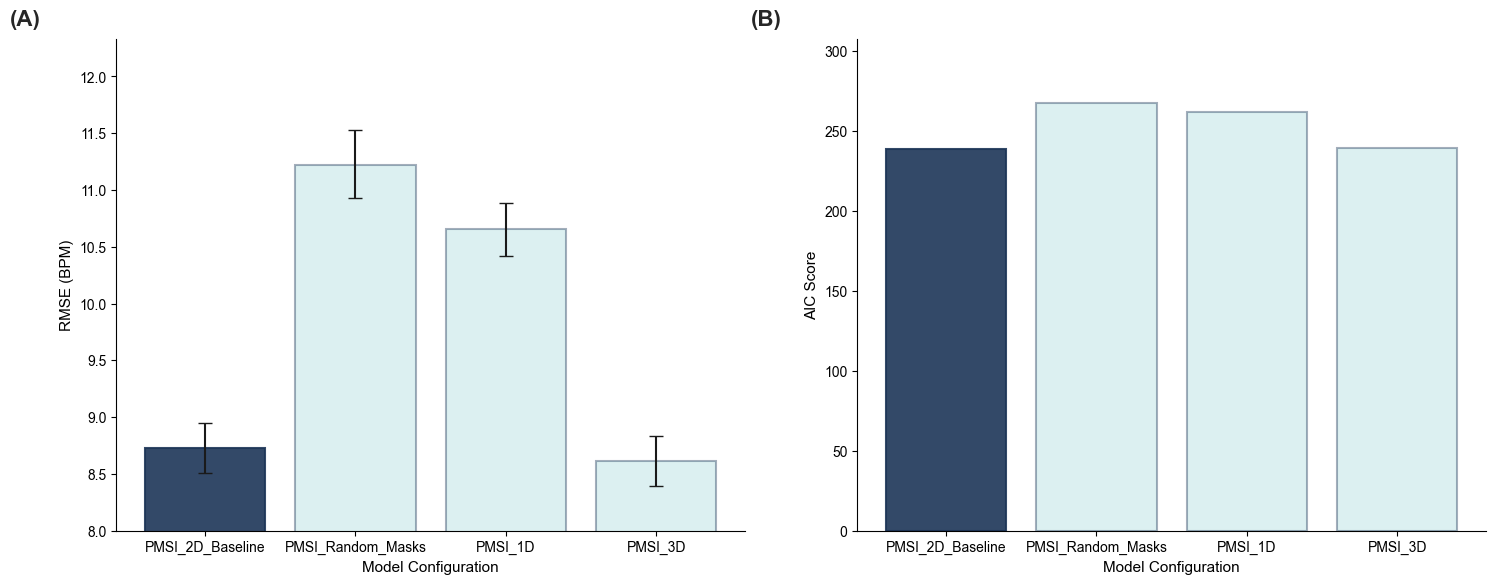


Quantitative Results Summary Table:


,Configuration,RMSE Mean,RMSE 95% CI,AIC
0,PMSI_2D_Baseline,8.7242,"[8.505, 8.949]",238.46
1,PMSI_Random_Masks,11.2222,"[10.927, 11.528]",267.09
2,PMSI_1D,10.6526,"[10.421, 10.887]",261.52
3,PMSI_3D,8.6096,"[8.396, 8.829]",239.36


In [9]:
print("5. Generating Comparative Side-by-Side Figure with 95% CIs and AIC...")
names = [r['name'] for r in results]
rmses = [r['df_summary'].loc[r['df_summary']['Metric'] == 'RMSE', 'Mean'].values[0] for r in results]
aics = [r['AIC'] for r in results]

ci_lowers = [r['df_summary'].loc[r['df_summary']['Metric'] == 'RMSE', 'CI_lower'].values[0] for r in results]
ci_uppers = [r['df_summary'].loc[r['df_summary']['Metric'] == 'RMSE', 'CI_upper'].values[0] for r in results]

yerr_lower = [m - l for m, l in zip(rmses, ci_lowers)]
yerr_upper = [u - m for m, u in zip(rmses, ci_uppers)]
yerr = np.array([yerr_lower, yerr_upper])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="white")

# Palette styling: baseline in darker blue, others in transparent light blue
colors = []
for name in names:
    if name == 'PMSI_2D_Baseline':
        colors.append('#1d3557')
    else:
        colors.append('#a8dadc')

# Left Subplot: RMSE Comparison with CIs
bars1 = ax1.bar(names, rmses, yerr=yerr, capsize=5, color=colors, edgecolor='#1d3557', linewidth=1.5)
for bar, name in zip(bars1, names):
    if name != 'PMSI_2D_Baseline':
        bar.set_alpha(0.4)
    else:
        bar.set_alpha(0.9)

ax1.text(-0.12, 1.02, "(A)", transform=ax1.transAxes, fontsize=16, fontweight="bold", va="bottom", ha="right")
ax1.set_ylabel("RMSE (BPM)", fontsize=11)
ax1.set_xlabel("Model Configuration", fontsize=11)
ax1.set_ylim(8.0, max(ci_uppers) + 0.8)
ax1.grid(False)
sns.despine(ax=ax1)

# Right Subplot: AIC Comparison Barplot
bars2 = ax2.bar(names, aics, color=colors, edgecolor='#1d3557', linewidth=1.5)
for bar, name in zip(bars2, names):
    if name != 'PMSI_2D_Baseline':
        bar.set_alpha(0.4)
    else:
        bar.set_alpha(0.9)

ax2.text(-0.12, 1.02, "(B)", transform=ax2.transAxes, fontsize=16, fontweight="bold", va="bottom", ha="right")
ax2.set_ylabel("AIC Score", fontsize=11)
ax2.set_xlabel("Model Configuration", fontsize=11)
ax2.set_ylim(0, max(aics) * 1.15)
ax2.grid(False)
sns.despine(ax=ax2)

plt.tight_layout()
plt.savefig("Figure_Ablation_Analysis.png", dpi=300)
plt.show()

print("\nQuantitative Results Summary Table:")
summary_rows = []
for r in results:
    row_rmse = r['df_summary'].loc[r['df_summary']['Metric'] == 'RMSE']
    mean = row_rmse['Mean'].values[0]
    lo = row_rmse['CI_lower'].values[0]
    hi = row_rmse['CI_upper'].values[0]
    
    summary_rows.append({
        'Configuration': r['name'],
        'RMSE Mean': f'{mean:.4f}',
        'RMSE 95% CI': f'[{lo:.3f}, {hi:.3f}]',
        'AIC': f'{r["AIC"]:.2f}'
    })
df_summary_print = pd.DataFrame(summary_rows)
import IPython.display as display
display.display(df_summary_print)


6. Visualizing Optimized 2D and Random Masks 2D PMSI Kernels...


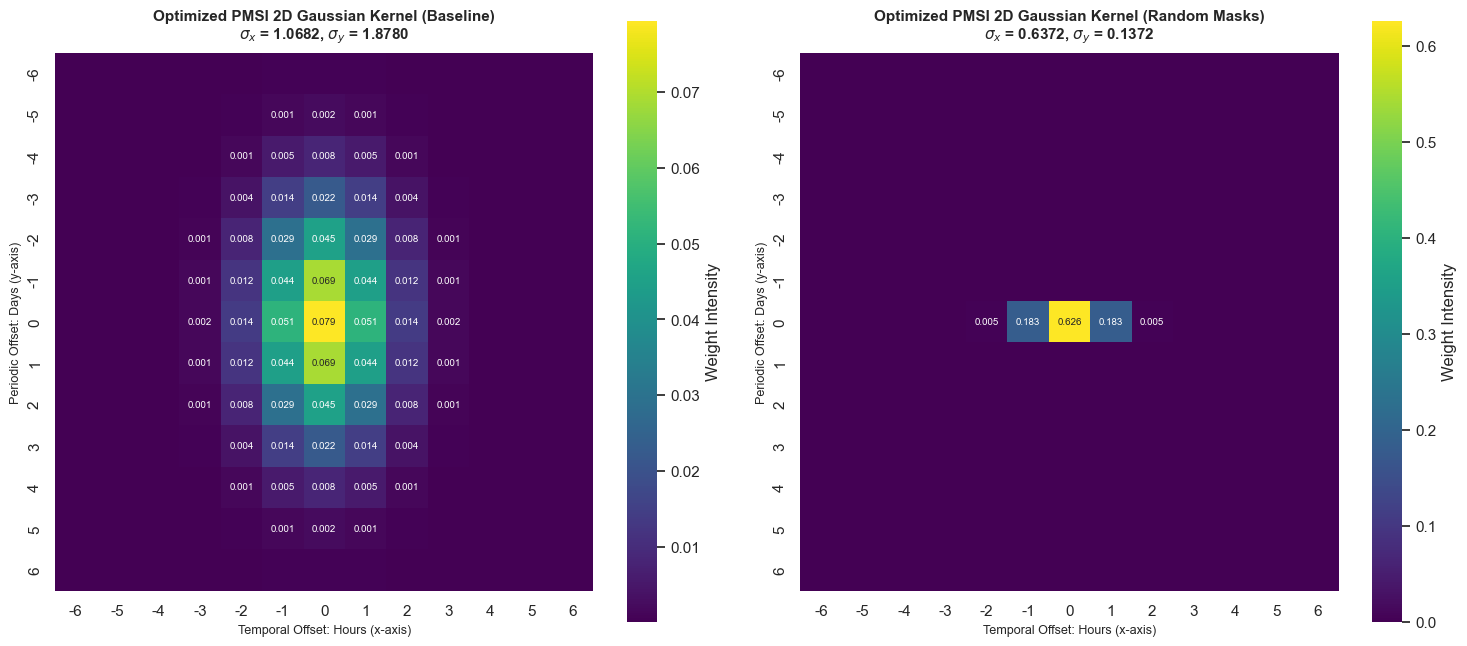

In [10]:
print("6. Visualizing Optimized 2D and Random Masks 2D PMSI Kernels...")
x_std_2d = pmsi_baseline.best_params_['x_1']
y_std_2d = pmsi_baseline.best_params_['x_0']
kernel_obj_2d = pmsi_baseline._get_kernel(x_std_2d, y_std_2d)
kernel_matrix_2d = kernel_obj_2d.array

x_std_rand = pmsi_ablation_1.best_params_['x_1']
y_std_rand = pmsi_ablation_1.best_params_['x_0']
kernel_obj_rand = pmsi_ablation_1._get_kernel(x_std_rand, y_std_rand)
kernel_matrix_rand = kernel_obj_rand.array

def get_annot_labels(matrix, threshold=0.0005):
    labels = np.empty(matrix.shape, dtype=object)
    for index, val in np.ndenumerate(matrix):
        if val > threshold:
            labels[index] = f'{val:.3f}'
        else:
            labels[index] = ''
    return labels

annot_2d = get_annot_labels(kernel_matrix_2d)
annot_rand = get_annot_labels(kernel_matrix_rand)

fig = plt.figure(figsize=(15, 6.5))
gs = fig.add_gridspec(1, 2)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

tick_labels = list(range(-6, 7))

# Subplot 1: 2D Heatmap for PMSI 2D Baseline
sns.heatmap(
    kernel_matrix_2d, 
    cmap='viridis', 
    annot=annot_2d, 
    fmt='', 
    annot_kws={'size': 7},
    cbar_kws={'label': 'Weight Intensity'},
    square=True,
    ax=ax1
)
ax1.set_title("Optimized PMSI 2D Gaussian Kernel (Baseline)\n" + f"$\\sigma_x$ = {x_std_2d:.4f}, $\\sigma_y$ = {y_std_2d:.4f}", fontsize=11, fontweight="bold", pad=10)
ax1.set_xlabel("Temporal Offset: Hours (x-axis)", fontsize=9)
ax1.set_ylabel("Periodic Offset: Days (y-axis)", fontsize=9)
ax1.set_xticks(np.arange(13) + 0.5)
ax1.set_xticklabels(tick_labels)
ax1.set_yticks(np.arange(13) + 0.5)
ax1.set_yticklabels(tick_labels)

# Subplot 2: 2D Heatmap for PMSI with Random Masks (Ablation 1)
sns.heatmap(
    kernel_matrix_rand, 
    cmap='viridis', 
    annot=annot_rand, 
    fmt='', 
    annot_kws={'size': 7},
    cbar_kws={'label': 'Weight Intensity'},
    square=True,
    ax=ax2
)
ax2.set_title("Optimized PMSI 2D Gaussian Kernel (Random Masks)\n" + f"$\\sigma_x$ = {x_std_rand:.4f}, $\\sigma_y$ = {y_std_rand:.4f}", fontsize=11, fontweight="bold", pad=10)
ax2.set_xlabel("Temporal Offset: Hours (x-axis)", fontsize=9)
ax2.set_ylabel("Periodic Offset: Days (y-axis)", fontsize=9)
ax2.set_xticks(np.arange(13) + 0.5)
ax2.set_xticklabels(tick_labels)
ax2.set_yticks(np.arange(13) + 0.5)
ax2.set_yticklabels(tick_labels)

plt.tight_layout()
plt.savefig("Figure_Kernel_Visualizations.png", dpi=300)
plt.show()
